In [151]:
def read_flash_bin(filepath: str = r"C:\Temp\bear\flash.bin") -> bytes:
    """Read a binary file and return its contents as a bytes array.
    
    Args:
        filepath: Path to the binary file (default: C:\\Temp\\bear\\flash.bin)
        
    Returns:
        bytes: The file contents as a byte array
    """
    with open(filepath, 'rb') as f:
        return f.read()


def load_u16_le(data: bytes, offset: int) -> int:
    """Load a 16-bit little-endian unsigned integer from the byte array.
    
    Args:
        data: The byte array to read from
        offset: The offset in the array to read from
        
    Returns:
        int: The 16-bit unsigned integer value (0-65535)
        
    Example:
        data = bytes([0x34, 0x12, 0x78, 0x56])
        load_u16_le(data, 0)  # Returns 0x1234 (4660)
        load_u16_le(data, 2)  # Returns 0x5678 (22136)
    """
    return data[offset] | (data[offset + 1] << 8)


def hexdump(data: bytes, offset: int = 0, length: int | None = None) -> str:
    """Format byte array in hexdump -C style.
    
    Args:
        data: The byte array to format
        offset: Starting offset in the data (default: 0)
        length: Number of bytes to display (default: all remaining bytes)
        
    Returns:
        str: Formatted hexdump string
        
    Example output:
        00000000  48 65 6c 6c 6f 20 57 6f  72 6c 64 21 0a           |Hello World!.|
    """
    if length is None:
        length = len(data) - offset
    
    lines = []
    bytes_processed = 0
    
    while bytes_processed < length:
        i = offset + bytes_processed
        remaining = length - bytes_processed
        chunk_size = min(16, remaining)
        chunk = data[i:i+chunk_size]
        
        # Address (8 hex digits)
        addr = f"{i:08x}"
        
        # Hex bytes (two groups of 8 bytes)
        hex_part1 = ' '.join(f"{b:02x}" for b in chunk[:8])
        hex_part2 = ' '.join(f"{b:02x}" for b in chunk[8:])
        
        # Pad if less than 16 bytes
        hex_part1 = hex_part1.ljust(23)  # 8 bytes * 3 chars - 1
        hex_part2 = hex_part2.ljust(23)
        
        # ASCII representation
        ascii_part = ''.join(chr(b) if 32 <= b <= 126 else '.' for b in chunk)
        
        lines.append(f"{addr}  {hex_part1} {hex_part2} |{ascii_part}|")
        bytes_processed += chunk_size
    
    return '\n'.join(lines)


# Example usage:
# data = read_flash_bin()
# print(hexdump(data, offset=0, length=256))  # First 256 bytes
# print(hexdump(data))  # All bytes

In [33]:
import glob
import os
import re
from types import SimpleNamespace

LOG_DIR = os.path.dirname(os.path.abspath("__file__"))


def _find_log_file(pattern: int, bit: int | None) -> str:
    """Locate the log file for a given pattern and bit (or noflip if bit is None)."""
    if bit is None:
        glob_pattern = os.path.join(LOG_DIR, f"pattern{pattern}_noflip_*.log")
    else:
        glob_pattern = os.path.join(LOG_DIR, f"pattern{pattern}_bit{bit}_*.log")
    matches = glob.glob(glob_pattern)
    if not matches:
        raise FileNotFoundError(f"No log file found matching: {glob_pattern}")
    if len(matches) > 1:
        raise ValueError(f"Multiple log files matched: {matches}")
    return matches[0]


def _parse_patching_row(path: str) -> tuple[int, int]:
    """
    Parse a log file and return the (address, count) of the row immediately
    following the first PATCHING record, both as integers.

    Raises ValueError if no PATCHING row is found or it is the last data row.
    """
    data_row = re.compile(r"^\s*\d+\s+(0x[0-9a-fA-F]+)\s+(\S+)")
    rows: list[tuple[str, str]] = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            m = data_row.match(line)
            if m:
                rows.append((m.group(1), m.group(2)))

    for i, (addr, count) in enumerate(rows):
        if count == "PATCHING":
            if i + 1 >= len(rows):
                raise ValueError(f"PATCHING is the last row in {path}")
            next_addr, next_count = rows[i + 1]
            return int(next_addr, 16), int(next_count)

    raise ValueError(f"No PATCHING row found in {path}")


def load_patching_result(
    pattern: int, bit: int | None = None
) -> SimpleNamespace:
    """
    Load the Address and Count values from the row immediately after PATCHING.

    Parameters
    ----------
    pattern : int
        Pattern number (0-4).
    bit : int or None
        Bit number (0-63). Pass None (default) to use the noflip log.

    Returns
    -------
    SimpleNamespace with attributes:
        .address  (int) – address parsed from hex
        .count    (int) – transaction count
        .file     (str) – source log filename
    """
    path = _find_log_file(pattern, bit)
    address, count = _parse_patching_row(path)
    return SimpleNamespace(address=address, count=count, file=os.path.basename(path))


In [34]:
import pandas as pd

PATTERNS = range(5)
BITS = range(64)

def _noflip_hex(pattern: int) -> int:
    """Return the hex value embedded in the noflip filename (the original pattern word)."""
    path = _find_log_file(pattern, None)
    m = re.search(r"_noflip_([0-9a-fA-F]+)\.log", os.path.basename(path))
    return int(m.group(1), 16)

def _flipped_hex(pattern: int, bit: int) -> int:
    """Return the hex value embedded in the bit filename (the flipped pattern word)."""
    path = _find_log_file(pattern, bit)
    m = re.search(r"_bit\d+_([0-9a-fA-F]+)\.log", os.path.basename(path))
    return int(m.group(1), 16)

flash_data = read_flash_bin()

rows = []
for pattern in PATTERNS:
    noflip = load_patching_result(pattern)
    noflip_word = _noflip_hex(pattern)
    for bit in BITS:
        flipped_word = _flipped_hex(pattern, bit)
        # Compare the two 64-bit words as unsigned ints: if noflip > flipped,
        # the original bit was 1 (it was flipped down to 0).
        orig_bit = 1 if noflip_word > flipped_word else 0
        sign = -1 if orig_bit == 1 else 1
        try:
            r = load_patching_result(pattern, bit)
            addr_xor   = noflip.address ^ r.address
            count_xor  = noflip.count   ^ r.count
            addr_diff  = sign * (r.address - noflip.address)
            count_diff = sign * (r.count   - noflip.count)
            if addr_diff < 0:
                addr_diff = 2**24 + addr_diff
            data_bytes = load_u16_le(flash_data, r.address % len(flash_data))
        except (FileNotFoundError, ValueError):
            addr_xor = count_xor = addr_diff = count_diff = data_bytes = None
        rows.append({
            "pattern":      pattern,
            "bit":          bit,
            "orig_bit":     orig_bit,
            "address_xor":  addr_xor,
            "count_xor":    count_xor,
            "address_diff": addr_diff,
            "count_diff":   count_diff,
            "data_bytes":   data_bytes,
        })

df = pd.DataFrame(rows)

def fmt_hex(v):
    return f"{v:#x}" if v is not None else "—"

df_display = df.copy()
df_display["address_xor"] = df_display["address_xor"].apply(fmt_hex)
df_display["count_xor"]   = df_display["count_xor"].apply(fmt_hex)

pd.set_option("display.max_rows", 20)
df_display

,pattern,bit,orig_bit,address_xor,count_xor,address_diff,count_diff
0,0,0,1,0xff0001,0x0,65535,0
1,0,1,0,0xfe0002,0x0,16646146,0
2,0,2,1,0xfc0004,0x0,262140,0
3,0,3,1,0xf80008,0x0,524280,0
4,0,4,0,0x100010,0xe,1048560,6
...,...,...,...,...,...,...,...
315,4,59,0,0x0,0x0,0,0
316,4,60,0,0x0,0x0,0,0
317,4,61,0,0x0,0x0,0,0
318,4,62,0,0x0,0x0,0,0


In [36]:
pivot = (
    df
    .pivot(index="bit", columns="pattern", values=["orig_bit", "address_diff"])
)
# Filter to show only bits 0-23
pivot = pivot.loc[0:23]

# Reorder columns: first all orig_bit by pattern, then all address_diff by pattern, then all address_xor by pattern
metric_order = ["orig_bit", "address_diff"]
pattern_order = sorted(pivot.columns.get_level_values("pattern").unique())

new_columns = []
for metric in metric_order:
    for pattern in pattern_order:
        new_columns.append((metric, pattern))

pivot = pivot.reindex(columns=new_columns)
pivot.columns.names = ["metric", "pattern"]

# Format XOR columns as hex, keep diff columns as plain ints
def fmt_cell(col_metric, v):
    if v is None:
        return "—"
    return f"{int(v):#x}"

pivot_display = pivot.copy().astype(object)
for (metric, pat) in pivot_display.columns:
    pivot_display[(metric, pat)] = pivot_display[(metric, pat)].apply(
        lambda v: fmt_cell(metric, v)
    )

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pivot_display

metric  orig_bit                     address_diff                      \
pattern        0    1    2    3    4            0         1         2   
bit                                                                     
0            0x1  0x1  0x1  0x1  0x0       0xffff    0xffff    0xffff   
1            0x0  0x1  0x0  0x0  0x0     0xfe0002  0xfe0002  0xfe0002   
2            0x1  0x1  0x0  0x0  0x0      0x3fffc   0x3fffc   0x3fffc   
3            0x1  0x1  0x1  0x0  0x0      0x7fff8   0x7fff8   0x7fff8   
4            0x0  0x1  0x1  0x0  0x0      0xffff0   0xffff0   0xffff0   
5            0x1  0x1  0x0  0x1  0x0     0xe00020  0xe00020  0xe00020   
6            0x0  0x1  0x1  0x1  0x0     0xc00040  0xc00040  0xc00040   
7            0x0  0x0  0x0  0x0  0x0     0x800080  0x800080  0x800080   
8            0x0  0x1  0x1  0x0  0x0        0x100     0x100     0x100   
9            0x0  0x0  0x1  0x0  0x0     0xfffe00  0xfffe00  0xfffe00   
10           0x0  0x1  0x0  0x1  0x0        0x400     0x400     0x400   
11           0x0  0x0  0x0  0x1  0x0        0x800     0x800     0x800   
12           0x0  0x0  0x1  0x1  0x0       0x1000    0x1000    0x1000   
13           0x0  0x1  0x1  0x1  0x0       0x2000    0x2000    0x2000   
14           0x0  0x0  0x0  0x1  0x0       0x4000    0x4000    0x4000   
15           0x0  0x1  0x1  0x0  0x0       0x8000    0x8000    0x8000   
16           0x1  0x1  0x1  0x1  0x0     0xff0000  0xff0000  0xff0000   
17           0x0  0x0  0x1  0x0  0x0      0x20000   0x20000   0x20000   
18           0x1  0x1  0x1  0x1  0x0     0xfc0000  0xfc0000  0xfc0000   
19           0x1  0x1  0x1  0x0  0x0     0xf80000  0xf80000  0xf80000   
20           0x0  0x0  0x1  0x1  0x0     0xf00000  0xf00000  0xf00000   
21           0x1  0x1  0x1  0x1  0x0     0x200000  0x200000  0x200000   
22           0x0  0x1  0x1  0x0  0x0     0x400000  0x400000  0x400000   
23           0x0  0x0  0x0  0x1  0x0     0x800000  0x800000  0x800000   

metric                       
pattern         3         4  
bit                          
0          0xffff    0xffff  
1        0xfe0002  0xfe0002  
2         0x3fffc   0x3fffc  
3         0x7fff8   0x7fff8  
4         0xffff0   0xffff0  
5        0xe00020  0xe00020  
6        0xc00040  0xc00040  
7        0x800080  0x800080  
8           0x100     0x100  
9        0xfffe00  0xfffe00  
10          0x400     0x400  
11          0x800     0x800  
12         0x1000    0x1000  
13         0x2000    0x2000  
14         0x4000    0x4000  
15         0x8000    0x8000  
16       0xff0000  0xff0000  
17        0x20000   0x20000  
18       0xfc0000  0xfc0000  
19       0xf80000  0xf80000  
20       0xf00000  0xf00000  
21       0x200000  0x200000  
22       0x400000  0x400000  
23       0x800000  0x800000

## Linear Map Analysis

Each bit represents a base vector (address_diff). The final address is given by a linear combination:
`address = base_address + sum(bit_i * base_vector_i)`

We'll form a matrix from these base vectors and check if it's invertible.

In [37]:
import numpy as np

# Work with pattern 0
pattern_0_data = df[df['pattern'] == 0].copy()

# Extract the base vectors (address_diff for each bit)
# These are the columns of our linear map matrix
base_vectors = pattern_0_data['address_diff'].values

print(f"Number of bits: {len(base_vectors)}")
print(f"Base vectors (address_diff) for pattern 0:")
for bit, addr_diff in enumerate(base_vectors[:24]):
    print(f"  Bit {bit:2d}: {addr_diff:10d} (0x{addr_diff:06x})")
print("  ...")

Number of bits: 64
Base vectors (address_diff) for pattern 0:
  Bit  0:      65535 (0x00ffff)
  Bit  1:   16646146 (0xfe0002)
  Bit  2:     262140 (0x03fffc)
  Bit  3:     524280 (0x07fff8)
  Bit  4:    1048560 (0x0ffff0)
  Bit  5:   14680096 (0xe00020)
  Bit  6:   12582976 (0xc00040)
  Bit  7:    8388736 (0x800080)
  Bit  8:        256 (0x000100)
  Bit  9:   16776704 (0xfffe00)
  Bit 10:       1024 (0x000400)
  Bit 11:       2048 (0x000800)
  Bit 12:       4096 (0x001000)
  Bit 13:       8192 (0x002000)
  Bit 14:      16384 (0x004000)
  Bit 15:      32768 (0x008000)
  Bit 16:   16711680 (0xff0000)
  Bit 17:     131072 (0x020000)
  Bit 18:   16515072 (0xfc0000)
  Bit 19:   16252928 (0xf80000)
  Bit 20:   15728640 (0xf00000)
  Bit 21:    2097152 (0x200000)
  Bit 22:    4194304 (0x400000)
  Bit 23:    8388608 (0x800000)
  ...


In [39]:
# Form a matrix where each column represents a base vector in binary form
# We need to represent each address_diff as a binary vector
# Since we're working with 24-bit addresses (based on the data), let's use 24 bits

# First, let's determine the address space size
max_address = max(base_vectors)
num_address_bits = 24
print(f"Maximum address: {max_address} (0x{max_address:x})")
print(f"Address space requires {num_address_bits} bits")

# Let's use 24 bits (common for address spaces)
ADDRESS_BITS = 24

# Create a matrix where:
# - Each column i corresponds to bit i in the encoding
# - Each row j corresponds to bit j in the address
# - Entry [j, i] = 1 if flipping bit i causes bit j in the address to change

matrix = np.zeros((ADDRESS_BITS, len(base_vectors)), dtype=int)

for bit_idx, addr_diff in enumerate(base_vectors):
    # Convert addr_diff to binary and fill the column
    for addr_bit in range(ADDRESS_BITS):
        if (addr_diff >> addr_bit) & 1:
            matrix[addr_bit, bit_idx] = 1

print(f"\nMatrix shape: {matrix.shape}")
print(f"Matrix (first 24 bits x first 24 bits):")
print(matrix[:24, :24])

Maximum address: 16776704 (0xfffe00)
Address space requires 24 bits

Matrix shape: (24, 64)
Matrix (first 24 bits x first 24 bits):
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 

In [40]:
# Check if the matrix is square and invertible
# For a matrix to be invertible, it must be square (n x n) and have full rank

print(f"Matrix dimensions: {matrix.shape[0]} x {matrix.shape[1]}")

if matrix.shape[0] == matrix.shape[1]:
    print("Matrix is square ✓")
    
    # Check rank
    rank = np.linalg.matrix_rank(matrix)
    print(f"Matrix rank: {rank}")
    print(f"Expected rank for invertibility: {matrix.shape[0]}")
    
    if rank == matrix.shape[0]:
        print("\n✓ Matrix has full rank - it is invertible!")
        
        # Try to compute determinant (should be non-zero for invertible matrices)
        # Note: for large matrices, this might overflow or be imprecise
        try:
            det = np.linalg.det(matrix.astype(float))
            print(f"Determinant: {det}")
        except:
            print("Determinant computation failed (matrix might be too large)")
    else:
        print(f"\n✗ Matrix does NOT have full rank (rank={rank} < dimension={matrix.shape[0]})")
        print("The matrix is NOT invertible")
else:
    print(f"Matrix is NOT square ({matrix.shape[0]} != {matrix.shape[1]})")
    
    # For non-square matrices, we can still check if it has full column/row rank
    rank = np.linalg.matrix_rank(matrix)
    min_dim = min(matrix.shape)
    print(f"Matrix rank: {rank}")
    print(f"Maximum possible rank: {min_dim}")
    
    if rank == min_dim:
        print("\n✓ Matrix has full rank (injective or surjective)")
    else:
        print(f"\n✗ Matrix does NOT have full rank")

Matrix dimensions: 24 x 64
Matrix is NOT square (24 != 64)
Matrix rank: 24
Maximum possible rank: 24

✓ Matrix has full rank (injective or surjective)


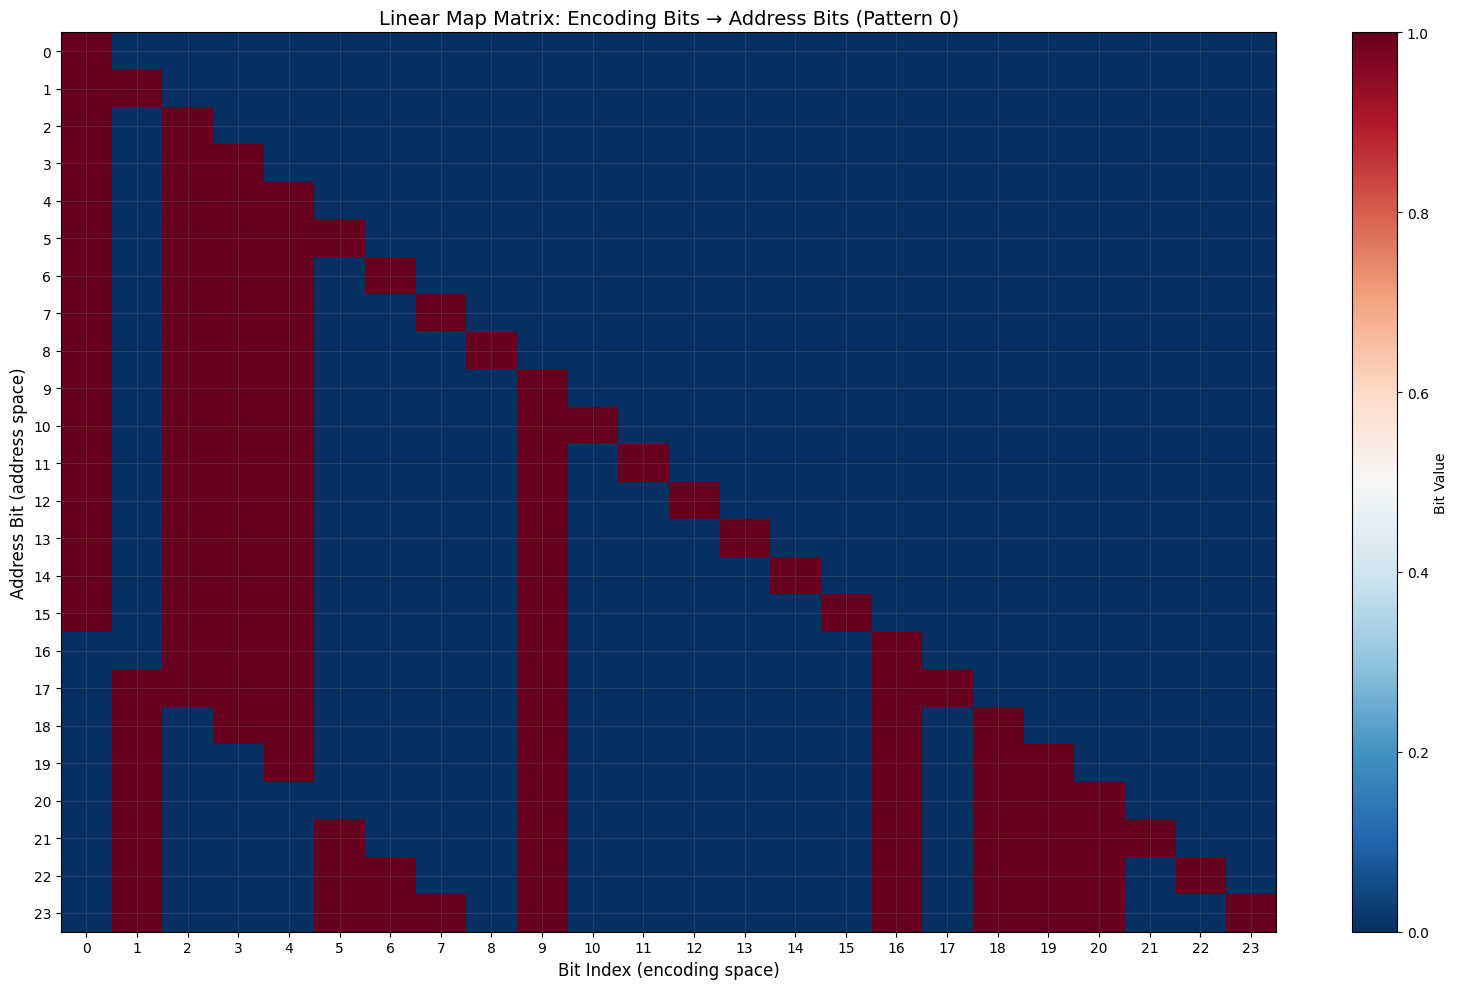


Matrix visualization:
- Each column represents how flipping one encoding bit affects the address
- Each row represents an address bit
- White (1) means the encoding bit affects that address bit
- Blue (0) means no effect


In [41]:
# Visualize the matrix structure to understand the linear map
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
im = ax.imshow(matrix[:24, :24], cmap='RdBu_r', aspect='auto', interpolation='nearest')
ax.set_xlabel('Bit Index (encoding space)', fontsize=12)
ax.set_ylabel('Address Bit (address space)', fontsize=12)
ax.set_title('Linear Map Matrix: Encoding Bits → Address Bits (Pattern 0)', fontsize=14)

# Add grid
ax.set_xticks(range(24))
ax.set_yticks(range(24))
ax.grid(True, alpha=0.3, color='gray', linewidth=0.5)

plt.colorbar(im, ax=ax, label='Bit Value')
plt.tight_layout()
plt.show()

print("\nMatrix visualization:")
print("- Each column represents how flipping one encoding bit affects the address")
print("- Each row represents an address bit")
print("- White (1) means the encoding bit affects that address bit")
print("- Blue (0) means no effect")

In [42]:
# Let's also check if working with only the non-zero bits gives us an invertible matrix
# Find which bits actually contribute (non-zero address_diff)

active_bits = pattern_0_data[pattern_0_data['address_diff'] != 0]['bit'].values
print(f"Number of active bits (non-zero address_diff): {len(active_bits)}")
print(f"Active bits: {active_bits}")

# Extract the submatrix corresponding only to active bits
active_matrix = matrix[:, active_bits]
print(f"\nActive submatrix shape: {active_matrix.shape}")

# Find which address bits are affected
affected_address_bits = np.where(active_matrix.any(axis=1))[0]
print(f"Number of affected address bits: {len(affected_address_bits)}")
print(f"Affected address bits: {affected_address_bits}")

# Create a square submatrix using only affected address bits and active encoding bits
if len(active_bits) == len(affected_address_bits):
    square_matrix = active_matrix[affected_address_bits, :]
    print(f"\nSquare submatrix shape: {square_matrix.shape}")
    
    rank = np.linalg.matrix_rank(square_matrix)
    print(f"Rank: {rank}")
    
    if rank == square_matrix.shape[0]:
        print("\n✓ Square submatrix is INVERTIBLE!")
        
        # Compute determinant
        det = np.linalg.det(square_matrix.astype(float))
        print(f"Determinant: {det}")
    else:
        print(f"\n✗ Square submatrix is NOT invertible (rank deficient)")
else:
    print(f"\nCannot form square matrix: {len(active_bits)} active bits but {len(affected_address_bits)} affected address bits")

Number of active bits (non-zero address_diff): 24
Active bits: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Active submatrix shape: (24, 24)
Number of affected address bits: 24
Affected address bits: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Square submatrix shape: (24, 24)
Rank: 24

✓ Square submatrix is INVERTIBLE!
Determinant: 1.0


In [43]:
# Analyze the linear map more carefully
# The matrix columns are the base vectors in the address space

print("Analysis of the linear map:")
print("="*60)

# Create a dataframe showing the base vectors
base_vector_df = pd.DataFrame({
    'bit': range(len(base_vectors)),
    'address_diff': base_vectors,
    'address_diff_hex': [f"0x{v:06x}" if v != 0 else "0" for v in base_vectors],
    'binary': [bin(v)[2:].zfill(24) if v != 0 else "0" * 24 for v in base_vectors]
})

# Show only non-zero entries
base_vector_df_nonzero = base_vector_df[base_vector_df['address_diff'] != 0]
print(f"\nNon-zero base vectors (pattern 0):")
print(base_vector_df_nonzero.to_string(index=False))

# Compute matrix properties
print(f"\nMatrix properties:")
print(f"  Full matrix shape: {matrix.shape}")
print(f"  Number of non-zero columns: {len(active_bits)}")
print(f"  Number of affected address bits: {len(affected_address_bits)}")

Analysis of the linear map:

Non-zero base vectors (pattern 0):
 bit  address_diff address_diff_hex                   binary
   0         65535         0x00ffff 000000001111111111111111
   1      16646146         0xfe0002 111111100000000000000010
   2        262140         0x03fffc 000000111111111111111100
   3        524280         0x07fff8 000001111111111111111000
   4       1048560         0x0ffff0 000011111111111111110000
   5      14680096         0xe00020 111000000000000000100000
   6      12582976         0xc00040 110000000000000001000000
   7       8388736         0x800080 100000000000000010000000
   8           256         0x000100 000000000000000100000000
   9      16776704         0xfffe00 111111111111111000000000
  10          1024         0x000400 000000000000010000000000
  11          2048         0x000800 000000000000100000000000
  12          4096         0x001000 000000000001000000000000
  13          8192         0x002000 000000000010000000000000
  14         16384   

In [44]:
# Since we likely have 64 bits but only 24 address bits, we need to check
# if the linear map restricted to the active subspace is invertible

# Create the matrix with base vectors as COLUMNS (standard linear algebra convention)
# Each column is a base vector represented as a binary vector
M = matrix.T  # Transpose so base vectors are rows, then we'll analyze

print(f"Transposed matrix shape: {M.shape}")
print(f"Interpretation: {M.shape[0]} encoding bits → {M.shape[1]} address bits")

# For invertibility, we need a square matrix
# Let's focus on the non-trivial part: active bits and affected address bits

if len(active_bits) > 0 and len(affected_address_bits) > 0:
    # Extract the relevant submatrix
    M_active = matrix[np.ix_(affected_address_bits, active_bits)]
    
    print(f"\nRelevant submatrix shape: {M_active.shape}")
    print(f"({len(affected_address_bits)} affected address bits × {len(active_bits)} active encoding bits)")
    
    rank = np.linalg.matrix_rank(M_active)
    min_dim = min(M_active.shape)
    
    print(f"\nRank analysis:")
    print(f"  Matrix rank: {rank}")
    print(f"  Number of rows: {M_active.shape[0]}")
    print(f"  Number of columns: {M_active.shape[1]}")
    print(f"  Min dimension: {min_dim}")
    
    if M_active.shape[0] == M_active.shape[1]:
        print(f"\n{'✓' if rank == M_active.shape[0] else '✗'} Submatrix is {'INVERTIBLE' if rank == M_active.shape[0] else 'NOT invertible'}")
        
        if rank == M_active.shape[0]:
            # Try to compute the inverse
            try:
                M_inv = np.linalg.inv(M_active.astype(float))
                print(f"\nInverse matrix computed successfully!")
                print(f"Verification: M @ M^(-1) should be identity")
                product = M_active.astype(float) @ M_inv
                is_identity = np.allclose(product, np.eye(M_active.shape[0]))
                print(f"Is product identity? {is_identity}")
            except np.linalg.LinAlgError as e:
                print(f"Failed to compute inverse: {e}")
    else:
        print(f"\n✗ Submatrix is NOT square, so it's not invertible in the traditional sense")
        print(f"  It is {'injective (one-to-one)' if rank == M_active.shape[1] else 'not injective'}")
        print(f"  It is {'surjective (onto)' if rank == M_active.shape[0] else 'not surjective'}")

Transposed matrix shape: (64, 24)
Interpretation: 64 encoding bits → 24 address bits

Relevant submatrix shape: (24, 24)
(24 affected address bits × 24 active encoding bits)

Rank analysis:
  Matrix rank: 24
  Number of rows: 24
  Number of columns: 24
  Min dimension: 24

✓ Submatrix is INVERTIBLE

Inverse matrix computed successfully!
Verification: M @ M^(-1) should be identity
Is product identity? True


In [45]:
# Let's check invertibility in GF(2) (binary field) since we're working with bits
# In GF(2), we use modulo 2 arithmetic

from scipy.linalg import lu

if len(active_bits) > 0 and len(affected_address_bits) > 0:
    M_active = matrix[np.ix_(affected_address_bits, active_bits)]
    
    if M_active.shape[0] == M_active.shape[1]:
        print("Checking invertibility over GF(2) (binary field):")
        print("="*60)
        
        # Compute rank over GF(2)
        # We'll use row reduction modulo 2
        M_gf2 = M_active.copy()
        n = M_gf2.shape[0]
        
        # Gaussian elimination over GF(2)
        rank_gf2 = 0
        pivot_row = 0
        
        for col in range(M_gf2.shape[1]):
            # Find pivot
            pivot_found = False
            for row in range(pivot_row, n):
                if M_gf2[row, col] % 2 == 1:
                    # Swap rows
                    M_gf2[[pivot_row, row]] = M_gf2[[row, pivot_row]]
                    pivot_found = True
                    break
            
            if not pivot_found:
                continue
            
            rank_gf2 += 1
            
            # Eliminate all other 1s in this column
            for row in range(n):
                if row != pivot_row and M_gf2[row, col] % 2 == 1:
                    M_gf2[row, :] = (M_gf2[row, :] + M_gf2[pivot_row, :]) % 2
            
            pivot_row += 1
        
        print(f"Rank over GF(2): {rank_gf2}")
        print(f"Matrix dimension: {n}")
        
        if rank_gf2 == n:
            print(f"\n✓ Matrix is INVERTIBLE over GF(2)!")
            print("This means the encoding is bijective - each encoded value maps uniquely to an address")
        else:
            print(f"\n✗ Matrix is NOT invertible over GF(2)")
            print(f"The encoding is not bijective (rank deficiency: {n - rank_gf2})")
    else:
        print(f"Matrix is not square: {M_active.shape[0]} x {M_active.shape[1]}")
        print("Cannot check standard invertibility")

Checking invertibility over GF(2) (binary field):
Rank over GF(2): 24
Matrix dimension: 24

✓ Matrix is INVERTIBLE over GF(2)!
This means the encoding is bijective - each encoded value maps uniquely to an address


In [46]:
# Additional analysis: check for linear independence of base vectors
# Two vectors are linearly independent if one cannot be written as a combination of others

print("Linear independence analysis:")
print("="*60)

if len(active_bits) > 0:
    # Check if any base vector can be written as XOR of others
    # In GF(2), this means checking if any column is in the span of the others
    
    M_active = matrix[np.ix_(affected_address_bits, active_bits)]
    
    print(f"Number of active base vectors: {len(active_bits)}")
    print(f"Dimension of address space (affected bits): {len(affected_address_bits)}")
    
    # Check pairwise XOR to see if there are obvious dependencies
    print("\nChecking for simple XOR relationships...")
    dependencies_found = []
    
    for i in range(min(10, len(active_bits))):  # Check first 10 for demo
        for j in range(i+1, min(10, len(active_bits))):
            vec_xor = base_vectors[active_bits[i]] ^ base_vectors[active_bits[j]]
            # Check if this XOR equals any other base vector
            for k in range(len(active_bits)):
                if k != i and k != j and base_vectors[active_bits[k]] == vec_xor:
                    dependencies_found.append((active_bits[i], active_bits[j], active_bits[k]))
                    print(f"  Found: base[{active_bits[i]}] XOR base[{active_bits[j]}] = base[{active_bits[k]}]")
    
    if not dependencies_found:
        print("  No simple XOR dependencies found (checked first 10 bits)")
    
    # The rank tells us the true dimension of the span
    print(f"\nRank of active submatrix: {np.linalg.matrix_rank(M_active)}")
    print(f"If rank equals number of active bits ({len(active_bits)}), they are linearly independent")

Linear independence analysis:
Number of active base vectors: 24
Dimension of address space (affected bits): 24

Checking for simple XOR relationships...
  No simple XOR dependencies found (checked first 10 bits)

Rank of active submatrix: 24
If rank equals number of active bits (24), they are linearly independent


## 16x16 Submatrix Analysis

Extract the upper left 16x16 submatrix (first 16 encoding bits → first 16 address bits) and check invertibility.

In [74]:
# Extract the upper left 16x16 submatrix
M_16x16 = matrix[:16, :16]

print("16x16 Submatrix:")
print(M_16x16)
print(f"\nShape: {M_16x16.shape}")

16x16 Submatrix:
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 1 0 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 0 0 1 0]
 [1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1]]

Shape: (16, 16)


In [75]:
# Check invertibility over real numbers first
rank_real = np.linalg.matrix_rank(M_16x16.astype(float))
print(f"Rank over real numbers: {rank_real}")
print(f"Matrix dimension: 16")

if rank_real == 16:
    print("\n✓ Matrix has full rank over reals!")
    
    # Compute determinant
    det = np.linalg.det(M_16x16.astype(float))
    print(f"Determinant: {det}")
    
    if abs(det) > 1e-10:
        print("✓ Determinant is non-zero - matrix is invertible over reals!")
else:
    print(f"\n✗ Matrix is rank deficient over reals (rank = {rank_real})")

Rank over real numbers: 16
Matrix dimension: 16

✓ Matrix has full rank over reals!
Determinant: 1.0
✓ Determinant is non-zero - matrix is invertible over reals!


In [77]:
# Check invertibility over GF(2) - the proper field for binary operations
# Use Gaussian elimination with modulo 2 arithmetic

def gf2_rank(matrix):
    """Compute rank of a binary matrix over GF(2)."""
    M = matrix.copy()
    n_rows, n_cols = M.shape
    
    rank = 0
    pivot_row = 0
    
    for col in range(n_cols):
        # Find pivot
        pivot_found = False
        for row in range(pivot_row, n_rows):
            if M[row, col] % 2 == 1:
                # Swap rows
                M[[pivot_row, row]] = M[[row, pivot_row]]
                pivot_found = True
                break
        
        if not pivot_found:
            continue
        
        rank += 1
        
        # Eliminate all other 1s in this column
        for row in range(n_rows):
            if row != pivot_row and M[row, col] % 2 == 1:
                M[row, :] = (M[row, :] + M[pivot_row, :]) % 2
        
        pivot_row += 1
    
    return rank

def gf2_inverse(matrix):
    """
    Compute inverse of a binary matrix over GF(2) using augmented matrix.
    Returns None if matrix is not invertible.
    """
    n = matrix.shape[0]
    if matrix.shape[0] != matrix.shape[1]:
        return None
    
    # Create augmented matrix [M | I]
    augmented = np.hstack([matrix.copy() % 2, np.eye(n, dtype=int)])
    
    # Forward elimination
    for col in range(n):
        # Find pivot
        pivot_row = None
        for row in range(col, n):
            if augmented[row, col] == 1:
                pivot_row = row
                break
        
        if pivot_row is None:
            return None  # Matrix is singular
        
        # Swap rows if needed
        if pivot_row != col:
            augmented[[col, pivot_row]] = augmented[[pivot_row, col]]
        
        # Eliminate all other 1s in this column
        for row in range(n):
            if row != col and augmented[row, col] == 1:
                augmented[row, :] = (augmented[row, :] + augmented[col, :]) % 2
    
    # Extract inverse from right half
    inverse = augmented[:, n:]
    return inverse

print("Checking invertibility over GF(2) (binary field):")
print("="*60)

rank_gf2 = gf2_rank(M_16x16)
print(f"Rank over GF(2): {rank_gf2}")
print(f"Matrix dimension: 16")

if rank_gf2 == 16:
    print("\n✓✓✓ Matrix is INVERTIBLE over GF(2)! ✓✓✓")
    print("This means the 16-bit encoding is bijective!")
    
    # Compute the inverse
    M_inv = gf2_inverse(M_16x16)
    if M_inv is not None:
        print("\n✓ Successfully computed inverse matrix!")
        print("\nInverse matrix (over GF(2)):")
        print(M_inv)
        
        # Verify: M @ M^(-1) should be identity (mod 2)
        product = (M_16x16 @ M_inv) % 2
        is_identity = np.array_equal(product, np.eye(16, dtype=int))
        print(f"\nVerification: M @ M^(-1) = I (mod 2)? {is_identity}")
        
        if is_identity:
            print("✓ Inverse verified correctly!")
    else:
        print("✗ Failed to compute inverse (unexpected)")
else:
    print(f"\n✗ Matrix is NOT invertible over GF(2)")
    print(f"Rank deficiency: {16 - rank_gf2}")

Checking invertibility over GF(2) (binary field):
Rank over GF(2): 16
Matrix dimension: 16

✓✓✓ Matrix is INVERTIBLE over GF(2)! ✓✓✓
This means the 16-bit encoding is bijective!

✓ Successfully computed inverse matrix!

Inverse matrix (over GF(2)):
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]]

Verification: M @ M^(-1) = I (mod 2)? True
✓ Inverse verified correctly!


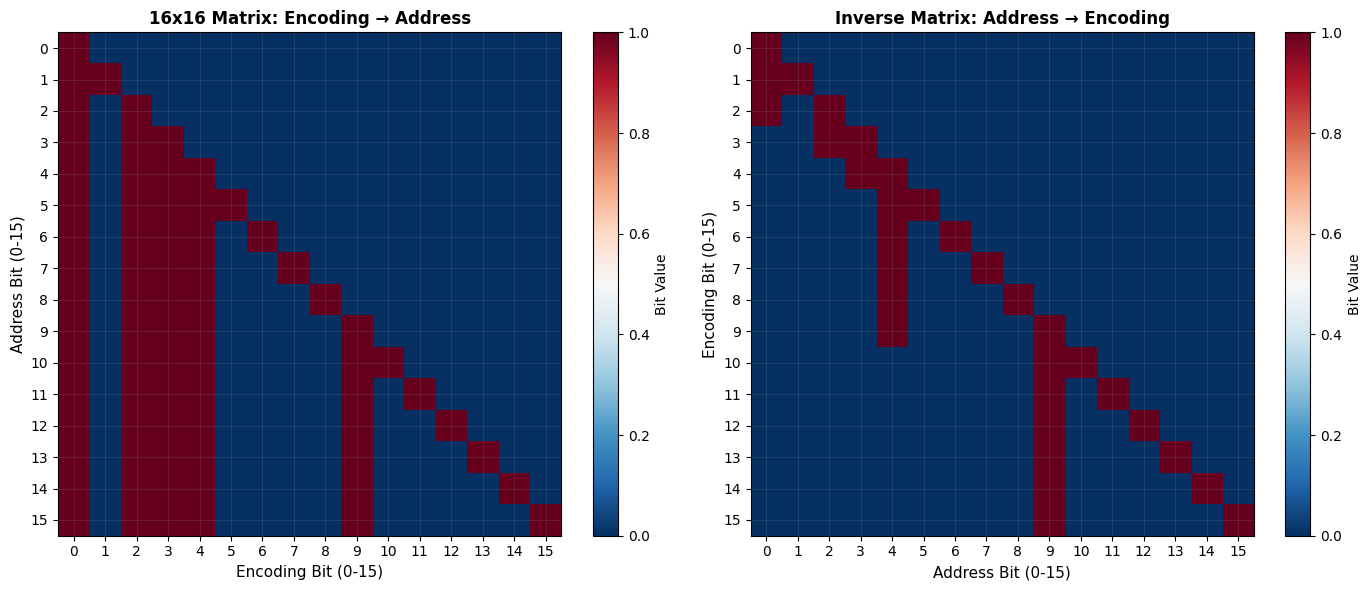

In [78]:
# Visualize the 16x16 matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original matrix
im1 = axes[0].imshow(M_16x16, cmap='RdBu_r', aspect='auto', interpolation='nearest')
axes[0].set_xlabel('Encoding Bit (0-15)', fontsize=11)
axes[0].set_ylabel('Address Bit (0-15)', fontsize=11)
axes[0].set_title('16x16 Matrix: Encoding → Address', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(16))
axes[0].set_yticks(range(16))
axes[0].grid(True, alpha=0.3, color='gray', linewidth=0.5)
plt.colorbar(im1, ax=axes[0], label='Bit Value')

# Inverse matrix (if it exists)
if rank_gf2 == 16 and M_inv is not None:
    im2 = axes[1].imshow(M_inv, cmap='RdBu_r', aspect='auto', interpolation='nearest')
    axes[1].set_xlabel('Address Bit (0-15)', fontsize=11)
    axes[1].set_ylabel('Encoding Bit (0-15)', fontsize=11)
    axes[1].set_title('Inverse Matrix: Address → Encoding', fontsize=12, fontweight='bold')
    axes[1].set_xticks(range(16))
    axes[1].set_yticks(range(16))
    axes[1].grid(True, alpha=0.3, color='gray', linewidth=0.5)
    plt.colorbar(im2, ax=axes[1], label='Bit Value')
else:
    axes[1].text(0.5, 0.5, 'Matrix not invertible', 
                ha='center', va='center', transform=axes[1].transAxes,
                fontsize=14)
    axes[1].set_xticks([])
    axes[1].set_yticks([])

plt.tight_layout()
plt.show()

In [79]:
# Show the base vectors for bits 0-15 in detail
print("Base vectors for encoding bits 0-15:")
print("="*70)
print(f"{'Bit':<4} {'Decimal':<10} {'Hex':<10} {'Binary (16 bits)':<20}")
print("-"*70)
for bit in range(16):
    addr_diff = base_vectors[bit]
    binary_str = format(addr_diff & 0xFFFF, '016b')
    print(f"{bit:<4} {addr_diff:<10} 0x{addr_diff:04x}    {binary_str}")
    
print("\nInterpretation:")
print("- Each row shows what address offset results from setting that encoding bit")
print("- The matrix columns are these base vectors in binary form")
print("- If invertible, we can decode any 16-bit address back to its encoding")

Base vectors for encoding bits 0-15:
Bit  Decimal    Hex        Binary (16 bits)    
----------------------------------------------------------------------
0    65535      0xffff    1111111111111111
1    16646146   0xfe0002    0000000000000010
2    262140     0x3fffc    1111111111111100
3    524280     0x7fff8    1111111111111000
4    1048560    0xffff0    1111111111110000
5    14680096   0xe00020    0000000000100000
6    12582976   0xc00040    0000000001000000
7    8388736    0x800080    0000000010000000
8    256        0x0100    0000000100000000
9    16776704   0xfffe00    1111111000000000
10   1024       0x0400    0000010000000000
11   2048       0x0800    0000100000000000
12   4096       0x1000    0001000000000000
13   8192       0x2000    0010000000000000
14   16384      0x4000    0100000000000000
15   32768      0x8000    1000000000000000

Interpretation:
- Each row shows what address offset results from setting that encoding bit
- The matrix columns are these base vectors in bin

## Encode/Decode Functions for 16-bit Submatrix

Functions to convert between 16-bit encoded values and 16-bit address offsets using the linear map.

In [80]:
def encode_16bit(encoded_value: int, pattern: int = 0) -> int:
    """
    Compute the 16-bit address offset from a 16-bit encoded value.
    
    Uses the linear map: address = M @ encoded (over GF(2))
    where M is the 16x16 matrix of base vectors.
    
    Parameters
    ----------
    encoded_value : int
        A 16-bit integer where each bit is a coefficient (0-65535)
    pattern : int
        Pattern number (0-4), default 0
        
    Returns
    -------
    int
        The resulting 16-bit address offset
        
    Examples
    --------
    >>> encode_16bit(0b0000000000000001)  # Only bit 0 set
    65535  # 0xffff - the base vector for bit 0
    
    >>> encode_16bit(0b0000000000000010)  # Only bit 1 set
    2  # Lower 16 bits of base vector for bit 1
    """
    # Get the base vectors for the specified pattern (first 16 bits only)
    pattern_data = df[df['pattern'] == pattern].copy()
    base_vectors_16 = pattern_data['address_diff'].values[:16]
    
    offset = 0
    
    # Compute linear combination: sum of (bit_i * base_vector_i)
    # In GF(2), addition is XOR
    for bit_idx in range(16):
        if (encoded_value >> bit_idx) & 1:  # If bit is set
            offset ^= base_vectors_16[bit_idx]  # XOR (addition in GF(2))
    
    # Keep result in 16-bit space
    offset = offset & 0xFFFF
    
    return offset


def decode_16bit(address_offset: int, pattern: int = 0) -> int:
    """
    Decode a 16-bit address offset back to the encoded value.
    
    Uses the inverse linear map: encoded = M^(-1) @ address (over GF(2))
    
    Parameters
    ----------
    address_offset : int
        A 16-bit address offset (0-65535)
    pattern : int
        Pattern number (0-4), default 0
        
    Returns
    -------
    int
        The original 16-bit encoded value
        
    Examples
    --------
    >>> decode_16bit(0xffff)  # Should give 0b0001 (bit 0)
    1
    
    Notes
    -----
    This function requires the 16x16 matrix to be invertible over GF(2).
    """
    # Check if inverse exists
    if 'M_inv' not in globals() or M_inv is None:
        raise ValueError("Inverse matrix not computed. Matrix may not be invertible.")
    
    # Convert address offset to binary vector
    address_vec = np.array([(address_offset >> i) & 1 for i in range(16)], dtype=int)
    
    # Apply inverse transformation: encoded = M^(-1) @ address (mod 2)
    encoded_vec = (M_inv @ address_vec) % 2
    
    # Convert binary vector back to integer
    encoded_value = 0
    for i in range(16):
        if encoded_vec[i]:
            encoded_value |= (1 << i)
    
    return encoded_value


# Numpy vectorized versions for batch processing
def encode_16bit_batch(encoded_values: np.ndarray, pattern: int = 0) -> np.ndarray:
    """
    Encode multiple 16-bit values at once using numpy.
    
    Parameters
    ----------
    encoded_values : np.ndarray
        Array of 16-bit integers to encode
    pattern : int
        Pattern number (0-4), default 0
        
    Returns
    -------
    np.ndarray
        Array of 16-bit address offsets
    """
    pattern_data = df[df['pattern'] == pattern].copy()
    base_vectors_16 = pattern_data['address_diff'].values[:16] & 0xFFFF
    
    # Convert to matrix multiplication over GF(2)
    # Each encoded value becomes a row of coefficients
    n = len(encoded_values)
    coeff_matrix = np.zeros((n, 16), dtype=int)
    
    for i, val in enumerate(encoded_values):
        for bit in range(16):
            coeff_matrix[i, bit] = (val >> bit) & 1
    
    # Matrix multiply and convert back
    result_matrix = (coeff_matrix @ M_16x16.T) % 2
    
    # Convert back to integers
    results = np.zeros(n, dtype=int)
    for i in range(n):
        for bit in range(16):
            if result_matrix[i, bit]:
                results[i] |= (1 << bit)
    
    return results


print("✓ Encoding/decoding functions defined:")
print("  - encode_16bit(encoded_value, pattern=0) -> address_offset")
print("  - decode_16bit(address_offset, pattern=0) -> encoded_value")
print("  - encode_16bit_batch(encoded_values, pattern=0) -> address_offsets")

✓ Encoding/decoding functions defined:
  - encode_16bit(encoded_value, pattern=0) -> address_offset
  - decode_16bit(address_offset, pattern=0) -> encoded_value
  - encode_16bit_batch(encoded_values, pattern=0) -> address_offsets


In [81]:
# Test the encoding/decoding functions
print("Testing encode_16bit and decode_16bit functions:")
print("="*70)

# Test 1: Individual bits
print("\nTest 1: Individual bits (should give base vectors)")
for bit in range(8):  # Test first 8 bits
    encoded = 1 << bit
    offset = encode_16bit(encoded, pattern=0)
    expected = base_vectors[bit] & 0xFFFF
    match = "✓" if offset == expected else "✗"
    print(f"  Bit {bit}: encode(0x{encoded:04x}) = 0x{offset:04x} (expected 0x{expected:04x}) {match}")

# Test 2: Decode should be inverse of encode
print("\nTest 2: Roundtrip encoding (encode -> decode should give original)")
test_values = [0x0001, 0x0002, 0x0004, 0x00FF, 0x1234, 0xABCD, 0xFFFF]
for test_val in test_values:
    offset = encode_16bit(test_val, pattern=0)
    decoded = decode_16bit(offset, pattern=0)
    match = "✓" if decoded == test_val else "✗"
    print(f"  0x{test_val:04x} -> encode -> 0x{offset:04x} -> decode -> 0x{decoded:04x} {match}")

# Test 3: Multiple bits (XOR property in GF(2))
print("\nTest 3: Linearity test (encode(a XOR b) = encode(a) XOR encode(b))")
a, b = 0x0F0F, 0x3333
enc_a = encode_16bit(a, pattern=0)
enc_b = encode_16bit(b, pattern=0)
enc_xor = encode_16bit(a ^ b, pattern=0)
expected_xor = enc_a ^ enc_b
match = "✓" if enc_xor == expected_xor else "✗"
print(f"  encode(0x{a:04x} XOR 0x{b:04x}) = 0x{enc_xor:04x}")
print(f"  encode(0x{a:04x}) XOR encode(0x{b:04x}) = 0x{expected_xor:04x}")
print(f"  Linearity verified: {match}")

Testing encode_16bit and decode_16bit functions:

Test 1: Individual bits (should give base vectors)
  Bit 0: encode(0x0001) = 0xffff (expected 0xffff) ✓
  Bit 1: encode(0x0002) = 0x0002 (expected 0x0002) ✓
  Bit 2: encode(0x0004) = 0xfffc (expected 0xfffc) ✓
  Bit 3: encode(0x0008) = 0xfff8 (expected 0xfff8) ✓
  Bit 4: encode(0x0010) = 0xfff0 (expected 0xfff0) ✓
  Bit 5: encode(0x0020) = 0x0020 (expected 0x0020) ✓
  Bit 6: encode(0x0040) = 0x0040 (expected 0x0040) ✓
  Bit 7: encode(0x0080) = 0x0080 (expected 0x0080) ✓

Test 2: Roundtrip encoding (encode -> decode should give original)
  0x0001 -> encode -> 0xffff -> decode -> 0x0001 ✓
  0x0002 -> encode -> 0x0002 -> decode -> 0x0002 ✓
  0x0004 -> encode -> 0xfffc -> decode -> 0x0004 ✓
  0x00ff -> encode -> 0x00e9 -> decode -> 0x00ff ✓
  0x1234 -> encode -> 0xee2c -> decode -> 0x1234 ✓
  0xabcd -> encode -> 0xa83b -> decode -> 0xabcd ✓
  0xffff -> encode -> 0x03e9 -> decode -> 0xffff ✓

Test 3: Linearity test (encode(a XOR b) = encode(

## Lower Right 16x16 Submatrix Analysis

Extract bits 8-23 (both encoding and address) and check invertibility.

In [160]:
# Extract the lower right 16x16 submatrix (bits 8-23 for both encoding and address)
M_16x16_lower = matrix[8:24, 8:24]

print("Lower Right 16x16 Submatrix (bits 8-23):")
print(M_16x16_lower)
print(f"\nShape: {M_16x16_lower.shape}")

Lower Right 16x16 Submatrix (bits 8-23):
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 1 1 1 1 0 0]
 [0 1 0 0 0 0 0 0 1 0 1 1 1 0 1 0]
 [0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 1]]

Shape: (16, 16)


In [161]:
# Check invertibility over real numbers first
rank_real_lower = np.linalg.matrix_rank(M_16x16_lower.astype(float))
print(f"Rank over real numbers: {rank_real_lower}")
print(f"Matrix dimension: 16")

if rank_real_lower == 16:
    print("\n✓ Matrix has full rank over reals!")
    
    # Compute determinant
    det_lower = np.linalg.det(M_16x16_lower.astype(float))
    print(f"Determinant: {det_lower}")
    
    if abs(det_lower) > 1e-10:
        print("✓ Determinant is non-zero - matrix is invertible over reals!")
else:
    print(f"\n✗ Matrix is rank deficient over reals (rank = {rank_real_lower})")

Rank over real numbers: 16
Matrix dimension: 16

✓ Matrix has full rank over reals!
Determinant: 1.0
✓ Determinant is non-zero - matrix is invertible over reals!


In [162]:
# Check invertibility over GF(2)
print("Checking invertibility over GF(2) (binary field):")
print("="*60)

rank_gf2_lower = gf2_rank(M_16x16_lower)
print(f"Rank over GF(2): {rank_gf2_lower}")
print(f"Matrix dimension: 16")

if rank_gf2_lower == 16:
    print("\n✓✓✓ Matrix is INVERTIBLE over GF(2)! ✓✓✓")
    print("The lower 16-bit encoding (bits 8-23) is bijective!")
    
    # Compute the inverse
    M_inv_lower = gf2_inverse(M_16x16_lower)
    if M_inv_lower is not None:
        print("\n✓ Successfully computed inverse matrix!")
        print("\nInverse matrix (over GF(2)):")
        print(M_inv_lower)
        
        # Verify: M @ M^(-1) should be identity (mod 2)
        product_lower = (M_16x16_lower @ M_inv_lower) % 2
        is_identity_lower = np.array_equal(product_lower, np.eye(16, dtype=int))
        print(f"\nVerification: M @ M^(-1) = I (mod 2)? {is_identity_lower}")
        
        if is_identity_lower:
            print("✓ Inverse verified correctly!")
    else:
        print("✗ Failed to compute inverse (unexpected)")
else:
    print(f"\n✗ Matrix is NOT invertible over GF(2)")
    print(f"Rank deficiency: {16 - rank_gf2_lower}")

Checking invertibility over GF(2) (binary field):
Rank over GF(2): 16
Matrix dimension: 16

✓✓✓ Matrix is INVERTIBLE over GF(2)! ✓✓✓
The lower 16-bit encoding (bits 8-23) is bijective!

✓ Successfully computed inverse matrix!

Inverse matrix (over GF(2)):
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1]]

Verification: M @ M^(-1) = I (mod 2)? True
✓ Inverse verified correctly!


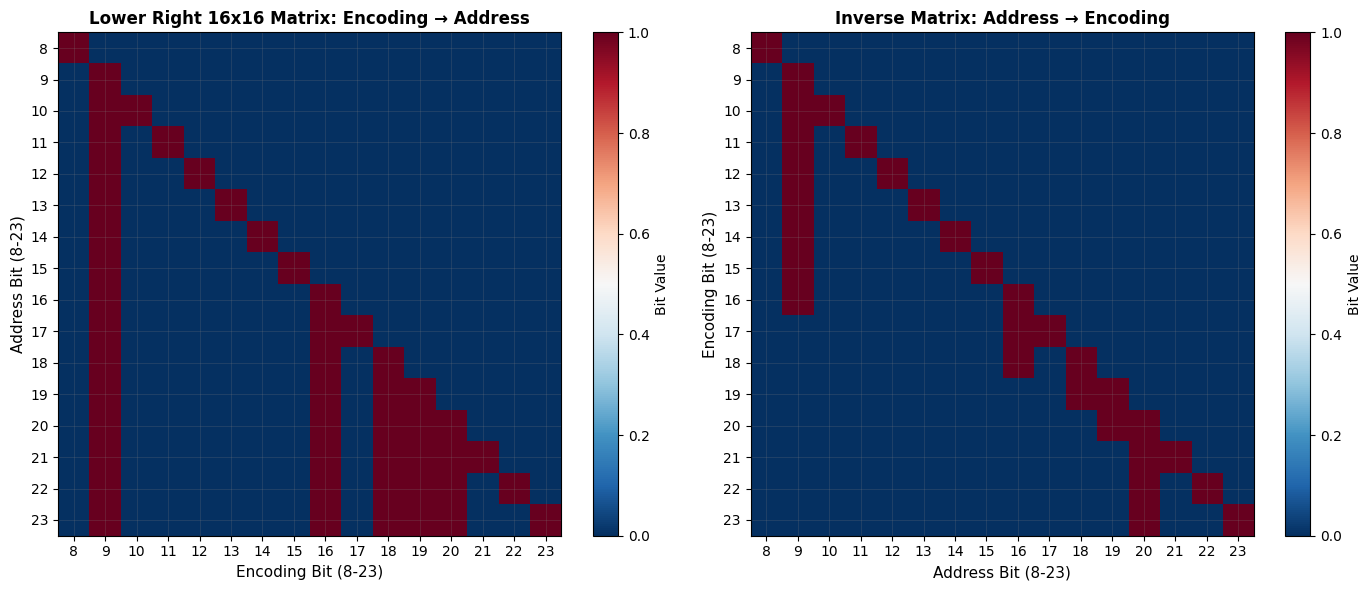

In [163]:
# Visualize the lower right 16x16 matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original matrix
im1 = axes[0].imshow(M_16x16_lower, cmap='RdBu_r', aspect='auto', interpolation='nearest')
axes[0].set_xlabel('Encoding Bit (8-23)', fontsize=11)
axes[0].set_ylabel('Address Bit (8-23)', fontsize=11)
axes[0].set_title('Lower Right 16x16 Matrix: Encoding → Address', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(16))
axes[0].set_xticklabels(range(8, 24))
axes[0].set_yticks(range(16))
axes[0].set_yticklabels(range(8, 24))
axes[0].grid(True, alpha=0.3, color='gray', linewidth=0.5)
plt.colorbar(im1, ax=axes[0], label='Bit Value')

# Inverse matrix (if it exists)
if rank_gf2_lower == 16 and M_inv_lower is not None:
    im2 = axes[1].imshow(M_inv_lower, cmap='RdBu_r', aspect='auto', interpolation='nearest')
    axes[1].set_xlabel('Address Bit (8-23)', fontsize=11)
    axes[1].set_ylabel('Encoding Bit (8-23)', fontsize=11)
    axes[1].set_title('Inverse Matrix: Address → Encoding', fontsize=12, fontweight='bold')
    axes[1].set_xticks(range(16))
    axes[1].set_xticklabels(range(8, 24))
    axes[1].set_yticks(range(16))
    axes[1].set_yticklabels(range(8, 24))
    axes[1].grid(True, alpha=0.3, color='gray', linewidth=0.5)
    plt.colorbar(im2, ax=axes[1], label='Bit Value')
else:
    axes[1].text(0.5, 0.5, 'Matrix not invertible', 
                ha='center', va='center', transform=axes[1].transAxes,
                fontsize=14)
    axes[1].set_xticks([])
    axes[1].set_yticks([])

plt.tight_layout()
plt.show()

In [164]:
# Show the base vectors for bits 8-23 in detail
print("Base vectors for encoding bits 8-23:")
print("="*70)
print(f"{'Bit':<4} {'Decimal':<10} {'Hex':<10} {'Binary (16 bits)':<20}")
print("-"*70)
for bit in range(8, 24):
    addr_diff = base_vectors[bit]
    # Extract bits 8-23 of the address offset
    addr_bits_8_23 = (addr_diff >> 8) & 0xFFFF
    binary_str = format(addr_bits_8_23, '016b')
    print(f"{bit:<4} {addr_diff:<10} 0x{addr_diff:06x}  {binary_str} (bits 8-23)")
    
print("\nNote: This submatrix shows how encoding bits 8-23 affect address bits 8-23")

Base vectors for encoding bits 8-23:
Bit  Decimal    Hex        Binary (16 bits)    
----------------------------------------------------------------------
8    256        0x000100  0000000000000001 (bits 8-23)
9    16776704   0xfffe00  1111111111111110 (bits 8-23)
10   1024       0x000400  0000000000000100 (bits 8-23)
11   2048       0x000800  0000000000001000 (bits 8-23)
12   4096       0x001000  0000000000010000 (bits 8-23)
13   8192       0x002000  0000000000100000 (bits 8-23)
14   16384      0x004000  0000000001000000 (bits 8-23)
15   32768      0x008000  0000000010000000 (bits 8-23)
16   16711680   0xff0000  1111111100000000 (bits 8-23)
17   131072     0x020000  0000001000000000 (bits 8-23)
18   16515072   0xfc0000  1111110000000000 (bits 8-23)
19   16252928   0xf80000  1111100000000000 (bits 8-23)
20   15728640   0xf00000  1111000000000000 (bits 8-23)
21   2097152    0x200000  0010000000000000 (bits 8-23)
22   4194304    0x400000  0100000000000000 (bits 8-23)
23   8388608    0x8

In [165]:
# Compare the structure of upper-left vs lower-right submatrices
print("Comparing Upper Left (0-15) vs Lower Right (8-23) Submatrices:")
print("="*70)

print("\nUpper Left (bits 0-15):")
print(f"  Rank: {rank_gf2}")
print(f"  Invertible: {rank_gf2 == 16}")
print(f"  Determinant (over reals): {det if rank_real == 16 else 'N/A'}")

print("\nLower Right (bits 8-23):")
print(f"  Rank: {rank_gf2_lower}")
print(f"  Invertible: {rank_gf2_lower == 16}")
print(f"  Determinant (over reals): {det_lower if rank_real_lower == 16 else 'N/A'}")

# Check if the matrices are similar in structure
if rank_gf2 == 16 and rank_gf2_lower == 16:
    print("\n✓ Both submatrices are invertible!")
    print("  This suggests the encoding scheme uses independent transformations")
    print("  for different bit ranges.")
else:
    print("\n✗ Submatrices have different invertibility properties")

Comparing Upper Left (0-15) vs Lower Right (8-23) Submatrices:

Upper Left (bits 0-15):
  Rank: 16
  Invertible: True
  Determinant (over reals): 1.0

Lower Right (bits 8-23):
  Rank: 16
  Invertible: True
  Determinant (over reals): 1.0

✓ Both submatrices are invertible!
  This suggests the encoding scheme uses independent transformations
  for different bit ranges.


## Encode/Decode Functions Using Lower Right 16x16 Submatrix

Functions to convert between 16-bit encoded values and 16-bit address offsets using bits 8-23.

In [167]:
def encode_16bit_lower(encoded_value: int, pattern: int = 0) -> int:
    """
    Compute the 16-bit address offset from a 16-bit encoded value.
    
    Uses the lower right 16x16 submatrix (bits 8-23).
    Linear map: address[8:23] = M @ encoded[8:23] (over GF(2))
    
    Parameters
    ----------
    encoded_value : int
        A 16-bit integer where each bit is a coefficient (0-65535)
    pattern : int
        Pattern number (0-4), default 0
        
    Returns
    -------
    int
        The resulting 16-bit address offset (bits 8-23 of full address)
        
    Examples
    --------
    >>> encode_16bit_lower(0b0000000000000001)  # Only bit 8 set
    # Returns bits 8-23 of base_vectors[8]
    """
    # Get the base vectors for bits 8-23
    pattern_data = df[df['pattern'] == pattern].copy()
    base_vectors_8_23 = pattern_data['address_diff'].values[8:24]
    
    offset = 0
    
    # Compute linear combination: sum of (bit_i * base_vector_i)
    # In GF(2), addition is XOR
    for bit_idx in range(16):
        if (encoded_value >> bit_idx) & 1:  # If bit is set
            # Extract bits 8-23 of the base vector
            base_vector_part = (base_vectors_8_23[bit_idx] >> 8) & 0xFFFF
            offset ^= base_vector_part  # XOR (addition in GF(2))
    
    # Result is already in 16-bit space
    offset = offset & 0xFFFF
    
    return offset


def decode_16bit_lower(address_offset: int, pattern: int = 0) -> int:
    """
    Decode a 16-bit address offset back to the encoded value.
    
    Uses the inverse of the lower right 16x16 submatrix (bits 8-23).
    Linear map: encoded[8:23] = M^(-1) @ address[8:23] (over GF(2))
    
    Parameters
    ----------
    address_offset : int
        A 16-bit address offset (0-65535), representing address bits 8-23
    pattern : int
        Pattern number (0-4), default 0
        
    Returns
    -------
    int
        The original 16-bit encoded value (representing encoding bits 8-23)
        
    Notes
    -----
    This function requires the lower 16x16 matrix to be invertible over GF(2).
    """
    # Check if inverse exists
    if 'M_inv_lower' not in globals() or M_inv_lower is None:
        raise ValueError("Inverse matrix not computed. Lower matrix may not be invertible.")
    
    # Convert address offset to binary vector
    address_vec = np.array([(address_offset >> i) & 1 for i in range(16)], dtype=int)
    
    # Apply inverse transformation: encoded = M^(-1) @ address (mod 2)
    encoded_vec = (M_inv_lower @ address_vec) % 2
    
    # Convert binary vector back to integer
    encoded_value = 0
    for i in range(16):
        if encoded_vec[i]:
            encoded_value |= (1 << i)
    
    return encoded_value


print("✓ Lower submatrix encoding/decoding functions defined:")
print("  - encode_16bit_lower(encoded_value, pattern=0) -> address_offset")
print("  - decode_16bit_lower(address_offset, pattern=0) -> encoded_value")
print("\nNote: These functions work with bits 8-23 of the encoding/address space")

✓ Lower submatrix encoding/decoding functions defined:
  - encode_16bit_lower(encoded_value, pattern=0) -> address_offset
  - decode_16bit_lower(address_offset, pattern=0) -> encoded_value

Note: These functions work with bits 8-23 of the encoding/address space


In [168]:
# Test the lower submatrix encoding/decoding functions
print("Testing encode_16bit_lower and decode_16bit_lower functions:")
print("="*70)

# Test 1: Individual bits
print("\nTest 1: Individual bits (should give bits 8-23 of base vectors)")
for bit in range(8, 16):  # Test bits 8-15
    encoded = 1 << (bit - 8)  # Bit position in 16-bit value
    offset = encode_16bit_lower(encoded, pattern=0)
    # Expected: bits 8-23 of base_vectors[bit]
    expected = (base_vectors[bit] >> 8) & 0xFFFF
    match = "✓" if offset == expected else "✗"
    print(f"  Bit {bit}: encode(0x{encoded:04x}) = 0x{offset:04x} (expected 0x{expected:04x}) {match}")

# Test 2: Decode should be inverse of encode
print("\nTest 2: Roundtrip encoding (encode -> decode should give original)")
test_values = [0x0001, 0x0002, 0x0004, 0x00FF, 0x1234, 0xABCD, 0xFFFF]
for test_val in test_values:
    offset = encode_16bit_lower(test_val, pattern=0)
    decoded = decode_16bit_lower(offset, pattern=0)
    match = "✓" if decoded == test_val else "✗"
    print(f"  0x{test_val:04x} -> encode -> 0x{offset:04x} -> decode -> 0x{decoded:04x} {match}")

# Test 3: Multiple bits (XOR property in GF(2))
print("\nTest 3: Linearity test (encode(a XOR b) = encode(a) XOR encode(b))")
a, b = 0x0F0F, 0x3333
enc_a = encode_16bit_lower(a, pattern=0)
enc_b = encode_16bit_lower(b, pattern=0)
enc_xor = encode_16bit_lower(a ^ b, pattern=0)
expected_xor = enc_a ^ enc_b
match = "✓" if enc_xor == expected_xor else "✗"
print(f"  encode(0x{a:04x} XOR 0x{b:04x}) = 0x{enc_xor:04x}")
print(f"  encode(0x{a:04x}) XOR encode(0x{b:04x}) = 0x{expected_xor:04x}")
print(f"  Linearity verified: {match}")

Testing encode_16bit_lower and decode_16bit_lower functions:

Test 1: Individual bits (should give bits 8-23 of base vectors)
  Bit 8: encode(0x0001) = 0x0001 (expected 0x0001) ✓
  Bit 9: encode(0x0002) = 0xfffe (expected 0xfffe) ✓
  Bit 10: encode(0x0004) = 0x0004 (expected 0x0004) ✓
  Bit 11: encode(0x0008) = 0x0008 (expected 0x0008) ✓
  Bit 12: encode(0x0010) = 0x0010 (expected 0x0010) ✓
  Bit 13: encode(0x0020) = 0x0020 (expected 0x0020) ✓
  Bit 14: encode(0x0040) = 0x0040 (expected 0x0040) ✓
  Bit 15: encode(0x0080) = 0x0080 (expected 0x0080) ✓

Test 2: Roundtrip encoding (encode -> decode should give original)
  0x0001 -> encode -> 0x0001 -> decode -> 0x0001 ✓
  0x0002 -> encode -> 0xfffe -> decode -> 0x0002 ✓
  0x0004 -> encode -> 0x0004 -> decode -> 0x0004 ✓
  0x00ff -> encode -> 0xff03 -> decode -> 0x00ff ✓
  0x1234 -> encode -> 0xf234 -> decode -> 0x1234 ✓
  0xabcd -> encode -> 0xa5cd -> decode -> 0xabcd ✓
  0xffff -> encode -> 0x1603 -> decode -> 0xffff ✓

Test 3: Linearity 

In [169]:
# Create a lookup table visualization for small examples
print("Example encoding/decoding pairs using lower submatrix (first 16 values):")
print("="*70)
print(f"{'Encoded':<10} {'Binary':<18} {'Address Offset':<15} {'Binary':<18}")
print("-"*70)

for i in range(16):
    offset = encode_16bit_lower(i, pattern=0)
    enc_bin = format(i, '016b')
    off_bin = format(offset, '016b')
    print(f"0x{i:04x}     {enc_bin}  ->  0x{offset:04x}        {off_bin}")

print("\nNote: This represents the transformation for bits 8-23 of the full encoding")

Example encoding/decoding pairs using lower submatrix (first 16 values):
Encoded    Binary             Address Offset  Binary            
----------------------------------------------------------------------
0x0000     0000000000000000  ->  0x0000        0000000000000000
0x0001     0000000000000001  ->  0x0001        0000000000000001
0x0002     0000000000000010  ->  0xfffe        1111111111111110
0x0003     0000000000000011  ->  0xffff        1111111111111111
0x0004     0000000000000100  ->  0x0004        0000000000000100
0x0005     0000000000000101  ->  0x0005        0000000000000101
0x0006     0000000000000110  ->  0xfffa        1111111111111010
0x0007     0000000000000111  ->  0xfffb        1111111111111011
0x0008     0000000000001000  ->  0x0008        0000000000001000
0x0009     0000000000001001  ->  0x0009        0000000000001001
0x000a     0000000000001010  ->  0xfff6        1111111111110110
0x000b     0000000000001011  ->  0xfff7        1111111111110111
0x000c     000000000000

In [170]:
# Compare the behavior of upper vs lower 16-bit transformations
print("Comparing Upper (bits 0-15) vs Lower (bits 8-23) Transformations:")
print("="*70)

# Test with the same encoded value for both
test_encoded = 0x1234

# Upper transformation (bits 0-15)
upper_result = encode_16bit(test_encoded, pattern=0)

# Lower transformation (bits 8-23)
lower_result = encode_16bit_lower(test_encoded, pattern=0)

print(f"\nTest encoded value: 0x{test_encoded:04x}")
print(f"  Upper transform (bits 0-15):  0x{upper_result:04x}")
print(f"  Lower transform (bits 8-23):  0x{lower_result:04x}")

if upper_result == lower_result:
    print("  → Same result (matrices may be identical)")
else:
    print("  → Different results (matrices have different transformations)")

# Test a few more values to confirm the pattern
print("\nTesting multiple values:")
for val in [0x0001, 0x00FF, 0x5555, 0xAAAA, 0xFFFF]:
    upper = encode_16bit(val, pattern=0)
    lower = encode_16bit_lower(val, pattern=0)
    same = "✓ same" if upper == lower else "✗ different"
    print(f"  0x{val:04x}: upper=0x{upper:04x}, lower=0x{lower:04x}  {same}")

Comparing Upper (bits 0-15) vs Lower (bits 8-23) Transformations:

Test encoded value: 0x1234
  Upper transform (bits 0-15):  0xee2c
  Lower transform (bits 8-23):  0xf234
  → Different results (matrices have different transformations)

Testing multiple values:
  0x0001: upper=0xffff, lower=0x0001  ✗ different
  0x00ff: upper=0x00e9, lower=0xff03  ✗ different
  0x5555: upper=0xaab3, lower=0xb355  ✗ different
  0xaaaa: upper=0xa95a, lower=0xa556  ✗ different
  0xffff: upper=0x03e9, lower=0x1603  ✗ different


## Lower Right 16x16 Submatrix Analysis

Extract the lower right 16x16 submatrix (encoding bits 48-63 → address bits 48-63) and check invertibility.

In [82]:
# Create a lookup table visualization for small examples
print("Example encoding/decoding pairs (first 16 values):")
print("="*70)
print(f"{'Encoded':<10} {'Binary':<18} {'Address Offset':<15} {'Binary':<18}")
print("-"*70)

for i in range(16):
    offset = encode_16bit(i, pattern=0)
    enc_bin = format(i, '016b')
    off_bin = format(offset, '016b')
    print(f"0x{i:04x}     {enc_bin}  ->  0x{offset:04x}        {off_bin}")

print("\nNote: This is a bijective mapping - every 16-bit encoded value maps")
print("      to a unique 16-bit address offset, and vice versa.")

Example encoding/decoding pairs (first 16 values):
Encoded    Binary             Address Offset  Binary            
----------------------------------------------------------------------
0x0000     0000000000000000  ->  0x0000        0000000000000000
0x0001     0000000000000001  ->  0xffff        1111111111111111
0x0002     0000000000000010  ->  0x0002        0000000000000010
0x0003     0000000000000011  ->  0xfffd        1111111111111101
0x0004     0000000000000100  ->  0xfffc        1111111111111100
0x0005     0000000000000101  ->  0x0003        0000000000000011
0x0006     0000000000000110  ->  0xfffe        1111111111111110
0x0007     0000000000000111  ->  0x0001        0000000000000001
0x0008     0000000000001000  ->  0xfff8        1111111111111000
0x0009     0000000000001001  ->  0x0007        0000000000000111
0x000a     0000000000001010  ->  0xfffa        1111111111111010
0x000b     0000000000001011  ->  0x0005        0000000000000101
0x000c     0000000000001100  ->  0x0004      

In [60]:
def compute_address_offset_numpy(encoded_value: int, pattern: int = 0) -> int:
    """
    Compute address offset using numpy (faster for multiple values).
    
    Parameters
    ----------
    encoded_value : int
        A 24-bit integer where each bit is a coefficient
    pattern : int
        Pattern number (0-4), default 0
        
    Returns
    -------
    int
        The resulting address offset
    """
    import numpy as np
    
    # Get base vectors
    pattern_data = df[df['pattern'] == pattern].copy()
    base_vectors = pattern_data['address_diff'].values[:24]
    
    # Convert encoded_value to binary coefficient array
    coefficients = np.array([(encoded_value >> i) & 1 for i in range(24)], dtype=int)
    
    # Compute dot product
    offset = np.dot(coefficients, base_vectors) + 0x21d
    
    return int(offset & 0xFFFFFF)

In [113]:
print(f'{hex(compute_address_offset_numpy(encoded_value=0x2d002d))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0x6da57f))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0x7fb359))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0xb57c61))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0x5b970d))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0x41943b))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0x59244d))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0x99c97d))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0x6bd37f))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0xa1a0c5))}')
print(f'{hex(compute_address_offset_numpy(encoded_value=0x47b763))}')



0x230
0xea762
0x1eb144
0x2c7e7c
0x369510
0x369626
0xf42650
0x24cb60
0x14d162
0xe4a2d8
0xdcb57e


|Segment|begin|end|
|-------|-|-|
|1|0x001eb144|0x002c7e7a|
|2|0x00ea762|0x01eb142|
|3|0x000230|0x00ea760|
|4|0x002c7e7c|0x00369506|



In [135]:
two_byte_offsets = [0x10246,
0x10272,
0x12a924,
0x16bb96,
0x1cb77c,
0x1e3524,
0x1eb1c2,
0x1ed7a4,
0x1fb204,
0x20a42,
0x2352,
0x2aaf3e,
0x2c67b2,
0x2c7d0c,
0x2c802a,
0x2d01c2,
0x2eb400,
0x347e7e,
0x404a0,
0x5eb164,
0x6babe,
0x79cc,
0x7d0,
0x8ea87a,
0x9eb164,
0x9eb68c,
0xac80fc,
0xc00274,
0xc004b3,
0xdeb164,
0xe03ab6,
0xe289e,
0xe88ea,
0xeba70,
0xf0039e]

In [172]:
data = read_flash_bin()
for off in two_byte_offsets:    
    print(format(decode_16bit_lower(load_u16_le(data, off % 2**22)), '016b'))


1101100000001011
0000100111101011
1000011011010111
1011001000011111
1110100011000100
0111001010010011
0101010110111101
0101001101011011
1001111110010010
0011011011010110
1000100011110111
1111000101001100
0001100010100101
0101101101001100
0100011101110100
1111010100010011
1011111111111111
1001100100011101
0101000110111110
0010110000010101
1110001111011110
1001100000101101
0010010111011110
1011111001001111
0010110000010101
1010011111110111
1111101000110000
0010110111111111
0011101001110111
0010110000010101
1111110110101010
0011010000001110
0101101110110011
0100010101010010
0001011100111101


In [176]:
import pandas as pd

def decode_bytes(hex_parts):
    """Decode hex strings, handling escape sequences: 4d 6a -> 4a, 4d 6d -> 4d"""
    result = []
    i = 0
    while i < len(hex_parts):
        val = int(hex_parts[i], 16)
        if val == 0x4d and i + 1 < len(hex_parts):
            next_val = int(hex_parts[i + 1], 16)
            if next_val == 0x6a:
                result.append(0x4a)
                i += 2
                continue
            elif next_val == 0x6d:
                result.append(0x4d)
                i += 2
                continue
        result.append(val)
        i += 1
    return result

# Load and parse the dump file
data = []

with open('bear2.dump', 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        
        # Decode escape sequences
        bytes_decoded = decode_bytes(parts)
        
        if len(bytes_decoded) < 7:
            continue
        
        # Ignore first value (bytes_decoded[0])
        # Concatenate bytes 2-4 into 24-bit offset (big-endian)
        offset = (bytes_decoded[1] << 16) | (bytes_decoded[2] << 8) | bytes_decoded[3]
        
        # Concatenate bytes 5-7 into 24-bit length (big-endian)
        length = (bytes_decoded[4] << 16) | (bytes_decoded[5] << 8) | bytes_decoded[6]
        
        # Concatenate bytes 8-9 into 16-bit timestamp if available
        timestamp = None
        if len(bytes_decoded) >= 9:
            timestamp = (bytes_decoded[7] << 8) | bytes_decoded[8]
        
        data.append({'offset': offset, 'length': length, 'timestamp': timestamp})

flash_data = read_flash_bin()

df2 = pd.DataFrame(data)

df2['data_bytes'] = df2['offset'].apply(
    lambda off: flash_data[off:off+2] if off + 2 <= len(flash_data) else None
)

# Timestamp unit in milliseconds
TS_UNIT_MS = 1.31072

# Compute timestamp difference to next row
df2['ts_diff'] = df2['timestamp'].shift(-1) - df2['timestamp']

# Add columns with millisecond values
df2['timestamp_ms'] = df2['timestamp'] * TS_UNIT_MS
df2['ts_diff_ms'] = df2['ts_diff'] * TS_UNIT_MS

print(f"Loaded {len(df)} records")
print(f"Records with timestamp: {df2['timestamp'].notna().sum()}")
print(f"Records without timestamp: {df2['timestamp'].isna().sum()}")
df2.head(20)

Loaded 320 records
Records with timestamp: 53201
Records without timestamp: 4993


,offset,length,timestamp,ts_diff,timestamp_ms,ts_diff_ms
0,240,4,57391.0,0.0,75223.53152,0.00000
1,528,8,57391.0,0.0,75223.53152,0.00000
2,2011460,4,57391.0,4.0,75223.53152,5.24288
3,2011464,68,57395.0,33.0,75228.77440,43.25376
4,2011532,80,57428.0,27.0,75272.02816,35.38944
5,2011612,76,57455.0,28.0,75307.41760,36.70016
6,2011688,76,57483.0,NaN,75344.11776,NaN
7,2011764,74,NaN,NaN,NaN,NaN
8,2011838,82,57539.0,26.0,75417.51808,34.07872
9,2011920,66,57565.0,28.0,75451.59680,36.70016
